## importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Load the data

In [3]:
df = pd.read_csv('Downloads/mental_tiredness_score_prediction_dataset.csv.csv')

In [4]:
df

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,70,196.5,65.1,7.0,136.1,1,7.84,26.75,2.05,Happy,Remote,Moderate Noise,53.8,19.8,3.3,22.17
1,122,9,66,256.4,135.2,6.5,83.9,3,7.18,17.82,1.82,Low,Remote,Noisy,38.9,18.7,4.6,25.35
2,113,4,55,387.3,54.2,10.0,176.5,5,5.52,27.78,1.92,Happy,Office,Quiet,42.0,26.4,7.9,34.36
3,113,8,45,300.3,107.1,4.8,164.7,2,8.47,3.48,1.89,Happy,Manual,Quiet,47.2,23.8,5.4,11.92
4,95,8,68,240.5,3.2,8.0,186.3,4,7.48,21.17,2.41,Happy,Manual,Moderate Noise,61.0,24.2,8.5,37.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,132,14,69,207.9,162.3,6.8,51.8,4,4.58,5.83,1.29,Low,Remote,Noisy,46.0,21.6,6.6,48.53
14996,111,11,49,365.2,69.4,7.7,67.0,1,7.39,18.18,1.65,Low,Student,Moderate Noise,42.0,26.0,6.6,50.75
14997,108,7,66,405.5,54.0,3.8,0.0,7,7.22,15.83,2.11,Low,Remote,Quiet,39.5,23.4,3.5,9.61
14998,143,8,64,402.8,18.2,3.0,0.0,5,7.89,16.72,0.38,Low,Office,Moderate Noise,54.4,27.1,6.0,32.05


In [5]:
df.head()

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,70,196.5,65.1,7.0,136.1,1,7.84,26.75,2.05,Happy,Remote,Moderate Noise,53.8,19.8,3.3,22.17
1,122,9,66,256.4,135.2,6.5,83.9,3,7.18,17.82,1.82,Low,Remote,Noisy,38.9,18.7,4.6,25.35
2,113,4,55,387.3,54.2,10.0,176.5,5,5.52,27.78,1.92,Happy,Office,Quiet,42.0,26.4,7.9,34.36
3,113,8,45,300.3,107.1,4.8,164.7,2,8.47,3.48,1.89,Happy,Manual,Quiet,47.2,23.8,5.4,11.92
4,95,8,68,240.5,3.2,8.0,186.3,4,7.48,21.17,2.41,Happy,Manual,Moderate Noise,61.0,24.2,8.5,37.45


In [6]:
df.shape

(15000, 18)

In [7]:
df.columns

Index(['number_of_decisions_made', 'context_switch_count',
       'notifications_received', 'screen_time_min', 'deep_work_min',
       'task_complexity_avg', 'caffeine_mg', 'break_frequency', 'sleep_hours',
       'deep_sleep_pct', 'hydration_l', 'mood', 'work_type',
       'work_environment', 'noise_level_db', 'temperature_c', 'workload_score',
       'mental_tiredness_score'],
      dtype='object')

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

number_of_decisions_made    0
context_switch_count        0
notifications_received      0
screen_time_min             0
deep_work_min               0
task_complexity_avg         0
caffeine_mg                 0
break_frequency             0
sleep_hours                 0
deep_sleep_pct              0
hydration_l                 0
mood                        0
work_type                   0
work_environment            0
noise_level_db              0
temperature_c               0
workload_score              0
mental_tiredness_score      0
dtype: int64

## Outlier detection & Treatment

{'whiskers': [<matplotlib.lines.Line2D at 0x1e27c8f16d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1e27c8f1950>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e27c7fd590>],
 'medians': [<matplotlib.lines.Line2D at 0x1e27c8f1bd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e27c8f1d10>],
 'means': []}

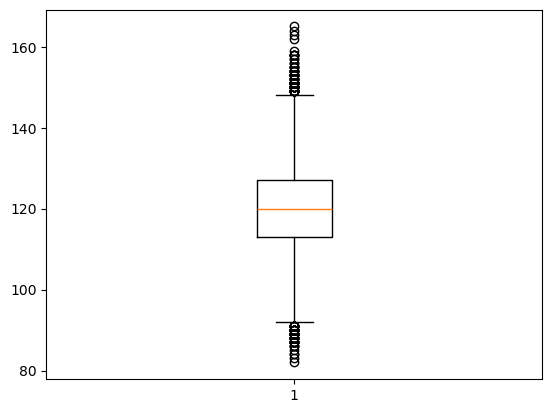

In [10]:
plt.boxplot(df['number_of_decisions_made'])

In [11]:
Q1 = df['number_of_decisions_made'].quantile(0.25)
Q3 = df['number_of_decisions_made'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df['number_of_decisions_made'] = df['number_of_decisions_made'].clip(
    lower=lower_limit,
    upper=upper_limit
)

{'whiskers': [<matplotlib.lines.Line2D at 0x1e20003a0d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1e20003a350>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e200039f90>],
 'medians': [<matplotlib.lines.Line2D at 0x1e20003a5d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e20003a710>],
 'means': []}

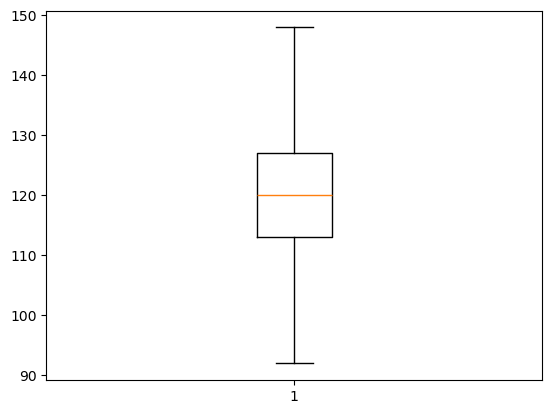

In [12]:
plt.boxplot(df['number_of_decisions_made'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1e2000b2350>,
 'caps': [<matplotlib.lines.Line2D at 0x1e2000b25d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e2000b2210>],
 'medians': [<matplotlib.lines.Line2D at 0x1e2000b2850>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e2000b2990>],
 'means': []}

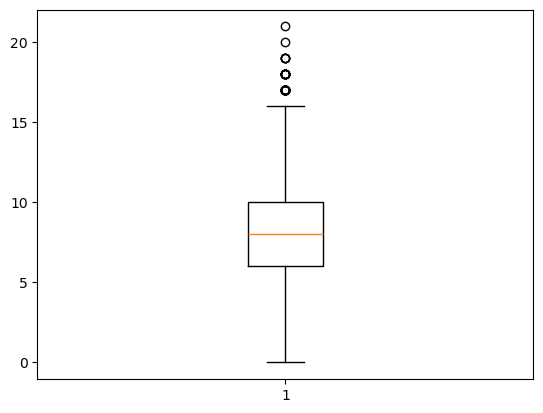

In [13]:
plt.boxplot(df['context_switch_count'])

In [14]:
Q1 = df['context_switch_count'].quantile(0.25)
Q3 = df['context_switch_count'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df['context_switch_count'] = df['context_switch_count'].clip(
    lower=lower_limit,
    upper=upper_limit
)

{'whiskers': [<matplotlib.lines.Line2D at 0x1e2002751d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1e200275450>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e200275090>],
 'medians': [<matplotlib.lines.Line2D at 0x1e2002756d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e200275810>],
 'means': []}

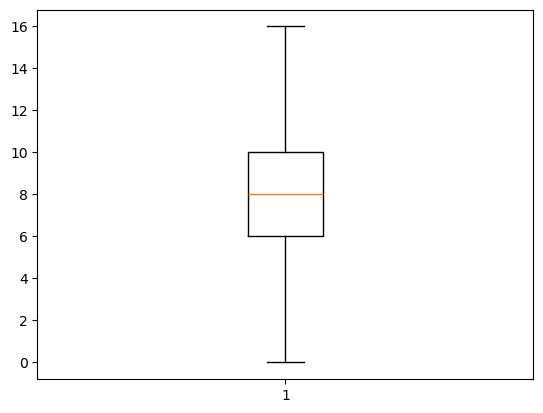

In [15]:
plt.boxplot(df['context_switch_count'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1e2002e1950>,
 'caps': [<matplotlib.lines.Line2D at 0x1e2002e1bd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e2002e1810>],
 'medians': [<matplotlib.lines.Line2D at 0x1e2002e1e50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e2002e1f90>],
 'means': []}

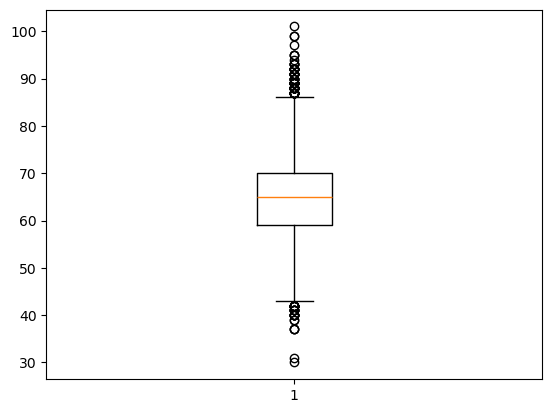

In [16]:
plt.boxplot(df['notifications_received'])

In [17]:
Q1 = df['notifications_received'].quantile(0.25)
Q3 = df['notifications_received'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df['notifications_received'] = df['notifications_received'].clip(
    lower=lower_limit,
    upper=upper_limit
)

{'whiskers': [<matplotlib.lines.Line2D at 0x1e200345950>,
 'caps': [<matplotlib.lines.Line2D at 0x1e200345bd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e200345810>],
 'medians': [<matplotlib.lines.Line2D at 0x1e200345e50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e200345f90>],
 'means': []}

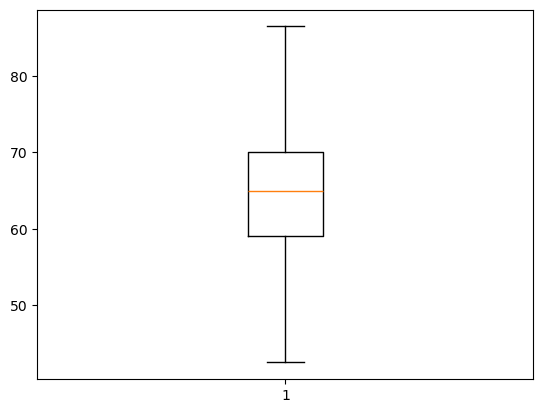

In [18]:
plt.boxplot(df['notifications_received'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1e200143b10>,
 'caps': [<matplotlib.lines.Line2D at 0x1e200143d90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e2001439d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1e200188050>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e200188190>],
 'means': []}

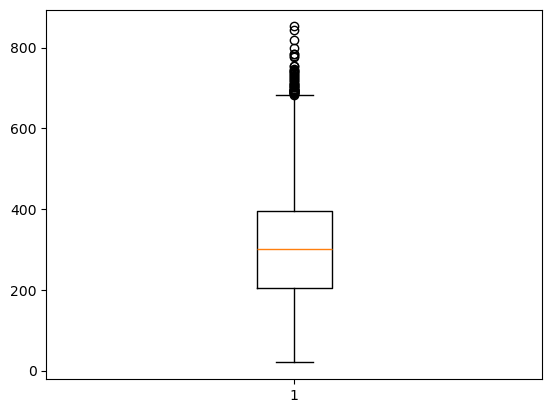

In [19]:
plt.boxplot(df['screen_time_min'])

In [20]:
Q1 = df['screen_time_min'].quantile(0.25)
Q3 = df['screen_time_min'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df['screen_time_min'] = df['screen_time_min'].clip(
    lower=lower_limit,
    upper=upper_limit
)

{'whiskers': [<matplotlib.lines.Line2D at 0x1e2001ca490>,
 'caps': [<matplotlib.lines.Line2D at 0x1e2001ca710>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e2001ca350>],
 'medians': [<matplotlib.lines.Line2D at 0x1e2001ca990>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e2001caad0>],
 'means': []}

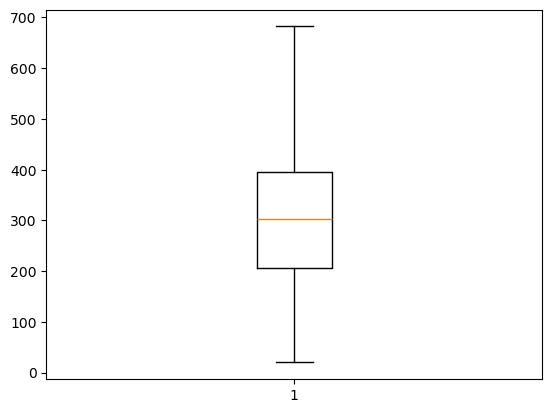

In [21]:
plt.boxplot(df['screen_time_min'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1e2004b6490>,
 'caps': [<matplotlib.lines.Line2D at 0x1e2004b6710>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e2004b6350>],
 'medians': [<matplotlib.lines.Line2D at 0x1e2004b6990>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e2004b6ad0>],
 'means': []}

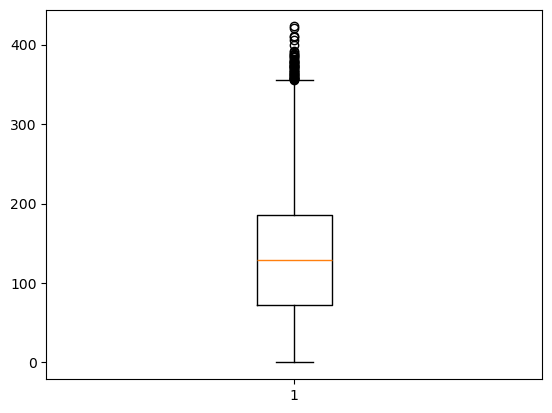

In [22]:
plt.boxplot(df['caffeine_mg'])

In [23]:
Q1 = df['caffeine_mg'].quantile(0.25)
Q3 = df['caffeine_mg'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df['caffeine_mg'] = df['caffeine_mg'].clip(
    lower=lower_limit,
    upper=upper_limit
)

{'whiskers': [<matplotlib.lines.Line2D at 0x1e200518e10>,
 'caps': [<matplotlib.lines.Line2D at 0x1e200519090>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e200518cd0>],
 'medians': [<matplotlib.lines.Line2D at 0x1e200519310>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e200519450>],
 'means': []}

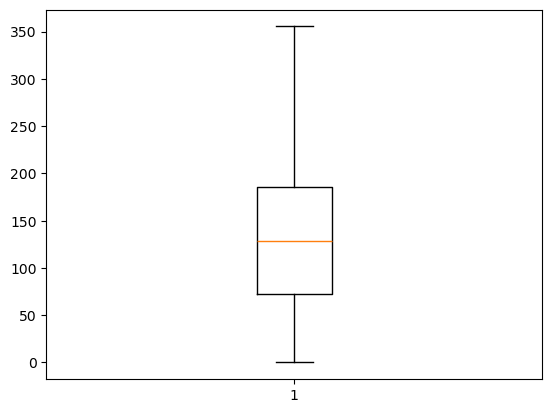

In [24]:
plt.boxplot(df['caffeine_mg'])

In [25]:
df.drop(['notifications_received','caffeine_mg'],axis = 1,inplace = True)

In [26]:
df.head()

,number_of_decisions_made,context_switch_count,screen_time_min,deep_work_min,task_complexity_avg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,196.5,65.1,7.0,1,7.84,26.75,2.05,Happy,Remote,Moderate Noise,53.8,19.8,3.3,22.17
1,122,9,256.4,135.2,6.5,3,7.18,17.82,1.82,Low,Remote,Noisy,38.9,18.7,4.6,25.35
2,113,4,387.3,54.2,10.0,5,5.52,27.78,1.92,Happy,Office,Quiet,42.0,26.4,7.9,34.36
3,113,8,300.3,107.1,4.8,2,8.47,3.48,1.89,Happy,Manual,Quiet,47.2,23.8,5.4,11.92
4,95,8,240.5,3.2,8.0,4,7.48,21.17,2.41,Happy,Manual,Moderate Noise,61.0,24.2,8.5,37.45


## Train test split

In [27]:
X = df.drop('mental_tiredness_score',axis = 1)
y = df['mental_tiredness_score']

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

## Encoding

In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [31]:


transform = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), ['mood', 'work_type', 'work_environment'])
    ],
    remainder='passthrough'
)

In [32]:
transform

ColumnTransformer(remainder='passthrough',
                  transformers=[('encoder', OneHotEncoder(),
                                 ['mood', 'work_type', 'work_environment'])])

In [33]:
X_train_transformed = transform.fit_transform(X_train)
X_test_transformed = transform.transform(X_test)

In [34]:
X_train_transformed

array([[ 0. ,  0. ,  1. , ..., 55.3, 25.6,  4.6],
       [ 0. ,  1. ,  0. , ..., 37.4, 26.6,  5.1],
       [ 0. ,  0. ,  1. , ..., 55.9, 20.2,  5.9],
       ...,
       [ 0. ,  1. ,  0. , ..., 46. , 20.3,  8.8],
       [ 0. ,  1. ,  0. , ..., 40.9, 23.1,  9.4],
       [ 0. ,  0. ,  1. , ..., 39.2, 22.1,  5.3]])

In [35]:
X_train_transformed = pd.DataFrame(X_train_transformed,columns = transform.get_feature_names_out())
X_test_transformed = pd.DataFrame(X_test_transformed,columns = transform.get_feature_names_out())

In [36]:
X_train_transformed.head()

,encoder__mood_Happy,encoder__mood_Low,encoder__mood_Neutral,encoder__work_type_Manual,encoder__work_type_Office,encoder__work_type_Remote,encoder__work_type_Student,encoder__work_environment_Moderate Noise,encoder__work_environment_Noisy,encoder__work_environment_Quiet,...,remainder__screen_time_min,remainder__deep_work_min,remainder__task_complexity_avg,remainder__break_frequency,remainder__sleep_hours,remainder__deep_sleep_pct,remainder__hydration_l,remainder__noise_level_db,remainder__temperature_c,remainder__workload_score
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,164.0,20.8,2.9,9.0,6.79,18.57,2.94,55.3,25.6,4.6
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,398.1,245.2,6.6,2.0,6.43,15.39,2.99,37.4,26.6,5.1
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,336.4,126.7,4.6,6.0,7.20,20.38,2.38,55.9,20.2,5.9
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,314.5,58.2,9.8,7.0,7.33,13.99,1.39,45.5,25.6,6.5
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,322.7,102.4,3.8,7.0,5.13,27.60,2.49,50.0,25.8,3.5


In [37]:
df.head()

,number_of_decisions_made,context_switch_count,screen_time_min,deep_work_min,task_complexity_avg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,196.5,65.1,7.0,1,7.84,26.75,2.05,Happy,Remote,Moderate Noise,53.8,19.8,3.3,22.17
1,122,9,256.4,135.2,6.5,3,7.18,17.82,1.82,Low,Remote,Noisy,38.9,18.7,4.6,25.35
2,113,4,387.3,54.2,10.0,5,5.52,27.78,1.92,Happy,Office,Quiet,42.0,26.4,7.9,34.36
3,113,8,300.3,107.1,4.8,2,8.47,3.48,1.89,Happy,Manual,Quiet,47.2,23.8,5.4,11.92
4,95,8,240.5,3.2,8.0,4,7.48,21.17,2.41,Happy,Manual,Moderate Noise,61.0,24.2,8.5,37.45


In [38]:
print(X_train.shape)
print(X_test.shape)

(12000, 15)
(3000, 15)


## scaling

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()


In [41]:
X_train_scaled = scaler.fit_transform(X_train_transformed)
X_test_scaled = scaler.transform(X_test_transformed)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_transformed)
X_test_scaled = scaler.transform(X_test_transformed)

In [43]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(12000, 22)
(3000, 22)


In [44]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_transformed.columns
)

X_train_scaled.head()

,encoder__mood_Happy,encoder__mood_Low,encoder__mood_Neutral,encoder__work_type_Manual,encoder__work_type_Office,encoder__work_type_Remote,encoder__work_type_Student,encoder__work_environment_Moderate Noise,encoder__work_environment_Noisy,encoder__work_environment_Quiet,...,remainder__screen_time_min,remainder__deep_work_min,remainder__task_complexity_avg,remainder__break_frequency,remainder__sleep_hours,remainder__deep_sleep_pct,remainder__hydration_l,remainder__noise_level_db,remainder__temperature_c,remainder__workload_score
0,-0.846604,-0.504163,1.277785,-0.330704,-0.663368,-0.567342,1.355810,-0.812251,-0.502082,1.221773,...,-1.017292,-1.246472,-1.325057,2.479926,-0.081620,-0.078426,1.523326,0.753673,0.875250,-0.566622
1,-0.846604,1.983484,-0.782604,-0.330704,-0.663368,1.762605,-0.737566,1.231147,-0.502082,-0.818483,...,0.708946,2.419812,0.557319,-0.991623,-0.359568,-0.611120,1.596200,-1.066491,1.212055,-0.308343
2,-0.846604,-0.504163,1.277785,-0.330704,1.507458,-0.567342,-0.737566,-0.812251,-0.502082,1.221773,...,0.253974,0.483740,-0.460182,0.992119,0.234933,0.224774,0.707132,0.814685,-0.943492,0.104905
3,1.181190,-0.504163,-0.782604,-0.330704,-0.663368,-0.567342,1.355810,-0.812251,-0.502082,1.221773,...,0.092485,-0.635424,2.185320,1.488055,0.335303,-0.845639,-0.735782,-0.242841,0.875250,0.414840
4,1.181190,-0.504163,-0.782604,-0.330704,1.507458,-0.567342,-0.737566,-0.812251,-0.502082,1.221773,...,0.152951,0.086723,-0.867182,1.488055,-1.363272,1.434224,0.867456,0.214742,0.942611,-1.134837


In [ ]:
X_train_scaled

# SPRINT-2 Model Building

## Baseline Model

### Linear regression

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train Model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Train Predictions
y_train_pred = lr.predict(X_train_scaled)

# Test Predictions
y_test_pred = lr.predict(X_test_scaled)

# Train Metrics
train_r2 = r2_score(y_train, y_train_pred)

# Test Metrics
test_r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Linear Regression Results")
print("-" * 30)
print("Train R2 Score :", train_r2)
print("Test R2 Score  :", test_r2)
print("MAE            :", mae)
print("RMSE           :", rmse)

Linear Regression Results
------------------------------
Train R2 Score : 0.7603532360302476
Test R2 Score  : 0.7678228005292559
MAE            : 4.679868937132935
RMSE           : 5.882168964808079


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Train multiple models

### DecisionTreeRegressor

In [46]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train Model
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train_scaled, y_train)

# Train Predictions
y_train_pred_dt = dt.predict(X_train_scaled)

# Test Predictions
y_test_pred_dt = dt.predict(X_test_scaled)

# Train Metrics
train_r2_dt = r2_score(y_train, y_train_pred_dt)

# Test Metrics
test_r2_dt = r2_score(y_test, y_test_pred_dt)
mae_dt = mean_absolute_error(y_test, y_test_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))

print("Decision Tree Results")
print("-" * 30)
print("Train R2 Score :", train_r2_dt)
print("Test R2 Score  :", test_r2_dt)
print("MAE            :", mae_dt)
print("RMSE           :", rmse_dt)

Decision Tree Results
------------------------------
Train R2 Score : 1.0
Test R2 Score  : 0.21805128661291684
MAE            : 8.579746666666667
RMSE           : 10.794855815001267


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


### RandomForestRegressor

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train Model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

# Train Predictions
y_train_pred_rf = rf.predict(X_train_scaled)

# Test Predictions
y_test_pred_rf = rf.predict(X_test_scaled)

# Train Metrics
train_r2_rf = r2_score(y_train, y_train_pred_rf)

# Test Metrics
test_r2_rf = r2_score(y_test, y_test_pred_rf)
mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print("Random Forest Results")
print("-" * 30)
print("Train R2 Score :", train_r2_rf)
print("Test R2 Score  :", test_r2_rf)
print("MAE            :", mae_rf)
print("RMSE           :", rmse_rf)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Random Forest Results
------------------------------
Train R2 Score : 0.9520807032674529
Test R2 Score  : 0.666622665481359
MAE            : 5.640934833333333
RMSE           : 7.048484453394928


### GradientBoostingRegressor

In [121]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Train Model
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train_scaled, y_train)

# Train Predictions
y_train_pred_gb = gb.predict(X_train_scaled)

# Test Predictions
y_test_pred_gb = gb.predict(X_test_scaled)

# Train Metrics
train_r2_gb = r2_score(y_train, y_train_pred_gb)

# Test Metrics
test_r2_gb = r2_score(y_test, y_test_pred_gb)
mae_gb = mean_absolute_error(y_test, y_test_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))

print("Gradient Boosting Results")
print("-" * 30)
print("Train R2 Score :", train_r2_gb)
print("Test R2 Score  :", test_r2_gb)
print("MAE            :", mae_gb)
print("RMSE           :", rmse_gb)

Gradient Boosting Results
------------------------------
Train R2 Score : 0.7474207222713987
Test R2 Score  : 0.7081961537912256
MAE            : 5.2718497701023095
RMSE           : 6.594368574183248


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


## check overfitting or underfitting

In [122]:
print("Linear Regression")
print("Train R2:", train_r2)
print("Test R2 :", test_r2)

print("\nDecision Tree")
print("Train R2:", train_r2_dt)
print("Test R2 :", test_r2_dt)

print("\nRandom Forest")
print("Train R2:", train_r2_rf)
print("Test R2 :", test_r2_rf)

print("\nGradient Boosting")
print("Train R2:", train_r2_gb)
print("Test R2 :", test_r2_gb)

Linear Regression
Train R2: 0.7603532360302476
Test R2 : 0.7678228005292559

Decision Tree
Train R2: 1.0
Test R2 : 0.21805128661291684

Random Forest
Train R2: 0.9520807032674529
Test R2 : 0.666622665481359

Gradient Boosting
Train R2: 0.7474207222713987
Test R2 : 0.7081961537912256


In [123]:
def check_model(train_r2, test_r2):
    
    diff = train_r2 - test_r2

    if train_r2 < 0.5 and test_r2 < 0.5:
        print("Underfitting")
        
    elif diff > 0.15:
        print("Overfitting")
        
    else:
        print("Good Fit")


print("Linear Regression")
check_model(train_r2, test_r2)

print("\nDecision Tree")
check_model(train_r2_dt, test_r2_dt)

print("\nRandom Forest")
check_model(train_r2_rf, test_r2_rf)

print("\nGradient Boosting")
check_model(train_r2_gb, test_r2_gb)

Linear Regression
Good Fit

Decision Tree
Overfitting

Random Forest
Overfitting

Gradient Boosting
Good Fit


## Model comparision Table

In [124]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [mae_lr, mae_dt, mae_rf, mae_gb],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf, rmse_gb],
    "R2 Score": [r2_lr, r2_dt, r2_rf, r2_gb]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.679869,5.882169,0.767823
3,Gradient Boosting,5.271850,6.594369,0.708196
2,Random Forest,5.640935,7.048484,0.666623
1,Decision Tree,8.579747,10.794856,0.218051


# SPRINT 3

## STEP 3 Hyper parameter tunning

In [52]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

params = {
    'alpha':[0.01,0.1,1,10,100]
}

grid_lr = GridSearchCV(
    Ridge(),
    param_grid=params,
    cv=5,
    scoring='r2'
)

grid_lr.fit(X_train_scaled,y_train)

print("Best Parameters:",grid_lr.best_params_)
print("Best Score:",grid_lr.best_score_)

Best Parameters: {'alpha': 10}
Best Score: 0.7591586200080096


In [54]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth':[3,5,10,15],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring='r2'
)

grid_dt.fit(X_train_scaled,y_train)

print("Best Parameters:",grid_dt.best_params_)
print("Best Score:",grid_dt.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Score: 0.3960701532651184


In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    rf,
    param_grid=params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best Score:", grid_rf.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.6508399747627702


In [49]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,5],
    'subsample':[0.8,1.0]
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring='r2'
)

grid_gb.fit(X_train_scaled,y_train)

print("Best Parameters:",grid_gb.best_params_)
print("Best Score:",grid_gb.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best Score: 0.7386225991367509


### best score

In [55]:
print("Linear Regression :",grid_lr.best_score_)
print("Decision Tree     :",grid_dt.best_score_)
print("Random Forest     :",grid_rf.best_score_)
print("Gradient Boosting :",grid_gb.best_score_)

Linear Regression : 0.7591586200080096
Decision Tree     : 0.3960701532651184
Random Forest     : 0.6508399747627702
Gradient Boosting : 0.7386225991367509


## STEP  4:Build final model

In [57]:
from sklearn.linear_model import LinearRegression

final_model = LinearRegression()

final_model.fit(X_train_scaled, y_train)

LinearRegression()

## STEP 5: FINAL EVALUATION

In [58]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = final_model.predict(X_test_scaled)

print("FINAL MODEL PERFORMANCE")
print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

FINAL MODEL PERFORMANCE
R2 Score : 0.7678228005292559
MAE      : 4.679868937132935
RMSE     : 5.882168964808079


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [63]:
import joblib

joblib.dump(final_model, "mental_tiredness_pipeline.pkl")

['mental_tiredness_pipeline.pkl']

In [64]:
model = joblib.load("mental_tiredness_pipeline.pkl")